Diagnostic overfitting / underfitting du Random Forest.

Principe simple : on recharge le modèle déjà entraîné et on compare son
score sur les données qu'il a vues (train) et celles qu'il n'a jamais vues
(test). Le split train/test doit être EXACTEMENT le même que dans
train_model.ipynb (même random_state, même test_size), sinon la
comparaison n'a aucun sens.

Comment lire le résultat :
- Train élevé + Test élevé + écart faible (<5-10 points)  -> bon fit
- Train élevé + Test nettement plus bas (écart >15 points) -> overfitting
  (le modèle a appris les données par coeur plutôt que le pattern général)
- Train bas + Test bas (les deux médiocres)                -> underfitting
  (le modèle n'arrive pas à apprendre, même sur ce qu'il a vu)

In [1]:
import os

import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, top_k_accuracy_score

In [2]:
SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

DATA_PATH = os.path.join(SCRIPT_DIR, "..", "..", "data", "cleaned_dataset.csv")
MODEL_DIR = os.path.join(SCRIPT_DIR, "..", "..", "models")

TARGET_COLUMN = "diseases"

# IMPORTANT : ces deux valeurs doivent être identiques à celles utilisées
# dans train_model.ipynb, sinon le split ne sera pas le même et la
# comparaison train/test ne voudra rien dire.
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [3]:
model_path = os.path.join(MODEL_DIR, "random_forest_model.pkl")
columns_path = os.path.join(MODEL_DIR, "symptom_columns.pkl")

if not os.path.isfile(model_path):
    raise FileNotFoundError(
        f"Modèle introuvable : {os.path.abspath(model_path)}\n"
        f"Avez-vous bien lancé train_model.ipynb avant ?"
    )

print("Chargement du modèle et des données...")
model = joblib.load(model_path)
symptom_columns = joblib.load(columns_path)

df = pd.read_csv(DATA_PATH)
X = df[symptom_columns]  # on force le même ordre de colonnes qu'à l'entraînement
y = df[TARGET_COLUMN]

Chargement du modèle et des données...


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train : {len(X_train)} lignes | Test : {len(X_test)} lignes")

Train : 197458 lignes | Test : 49365 lignes


In [5]:
def evaluate(model, X, y, label):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    acc = accuracy_score(y, y_pred)
    top4 = top_k_accuracy_score(y, y_proba, k=4, labels=model.classes_)
    print(f"{label:5s} -> top-1 : {acc:.3f}  |  top-4 : {top4:.3f}")
    return acc, top4

print("Calcul des scores (peut prendre un moment sur le train, ~200k lignes)...\n")
train_acc, train_top4 = evaluate(model, X_train, y_train, "Train")
test_acc, test_top4 = evaluate(model, X_test, y_test, "Test")

Calcul des scores (peut prendre un moment sur le train, ~200k lignes)...

Train -> top-1 : 0.810  |  top-4 : 0.897
Test  -> top-1 : 0.773  |  top-4 : 0.890


In [6]:
gap = train_acc - test_acc

print(f"\nÉcart train/test (top-1) : {gap:.3f}")

if train_acc < 0.5 and test_acc < 0.5:
    print("-> UNDERFITTING probable : le modèle peine même sur les données "
          "qu'il a vues. Pistes : augmenter MAX_DEPTH, augmenter N_ESTIMATORS, "
          "vérifier que les symptômes sont assez informatifs.")
elif gap > 0.15:
    print("-> OVERFITTING probable : le modèle est bien meilleur sur le train "
          "que sur le test. Pistes : baisser MAX_DEPTH, augmenter "
          "MIN_SAMPLES_LEAF, réduire N_ESTIMATORS, ou vérifier s'il y a des "
          "quasi-doublons entre train et test.")
else:
    print("-> Écart raisonnable, pas de signe fort d'overfitting ni "
          "d'underfitting. Le modèle généralise correctement.")


Écart train/test (top-1) : 0.037
-> Écart raisonnable, pas de signe fort d'overfitting ni d'underfitting. Le modèle généralise correctement.


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier


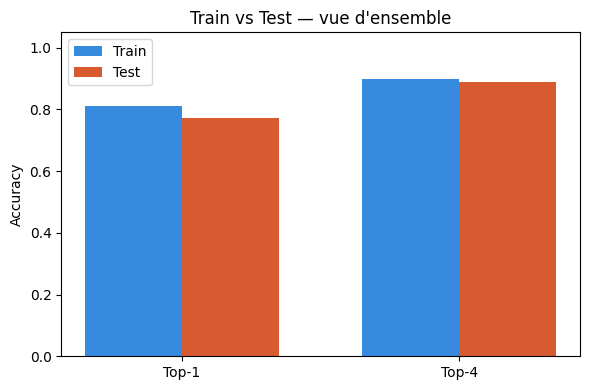

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Top-1", "Top-4"]
train_scores = [train_acc, train_top4]
test_scores = [test_acc, test_top4]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, train_scores, width, label="Train", color="#378ADD")
ax.bar(x + width / 2, test_scores, width, label="Test", color="#D85A30")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test — vue d'ensemble")
ax.legend()
plt.tight_layout()
plt.show()

Calcul de la learning curve (peut prendre plusieurs minutes)...


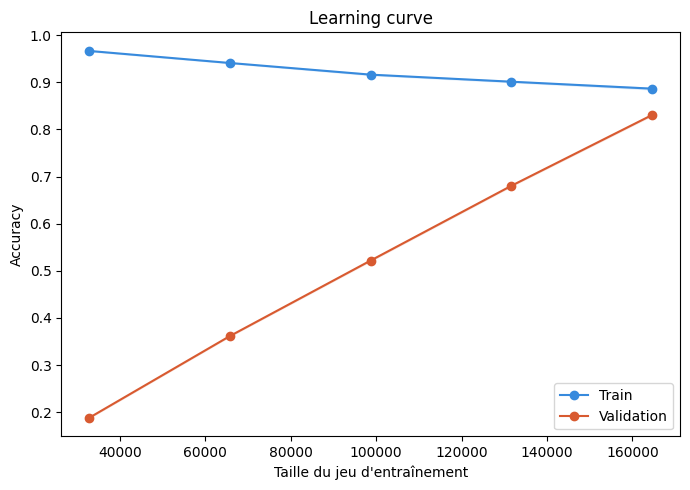

In [14]:
from sklearn.model_selection import learning_curve

# Version plus légère du modèle pour cette courbe (elle réentraîne plusieurs
# fois en interne -> coûteux avec 200 arbres sur 750 classes). 50 arbres
# suffisent largement pour voir la tendance générale.
N_JOBS = 2
MAX_DEPTH = 50
MIN_SAMPLES_LEAF = 2
N_ESTIMATORS = 200

light_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE, n_jobs=N_JOBS,
)

print("Calcul de la learning curve (peut prendre plusieurs minutes)...")
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    light_model, X, y, cv=3, train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="accuracy", n_jobs=N_JOBS,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_scores_lc.mean(axis=1), "o-", label="Train", color="#378ADD")
ax.plot(train_sizes, val_scores_lc.mean(axis=1), "o-", label="Validation", color="#D85A30")
ax.fill_between(train_sizes,
                 train_scores_lc.mean(axis=1) - train_scores_lc.std(axis=1),
                 train_scores_lc.mean(axis=1) + train_scores_lc.std(axis=1),
                 alpha=0.15, color="#378ADD")
ax.fill_between(train_sizes,
                 val_scores_lc.mean(axis=1) - val_scores_lc.std(axis=1),
                 val_scores_lc.mean(axis=1) + val_scores_lc.std(axis=1),
                 alpha=0.15, color="#D85A30")
ax.set_xlabel("Taille du jeu d'entraînement")
ax.set_ylabel("Accuracy")
ax.set_title("Learning curve")
ax.legend()
plt.tight_layout()
plt.show()

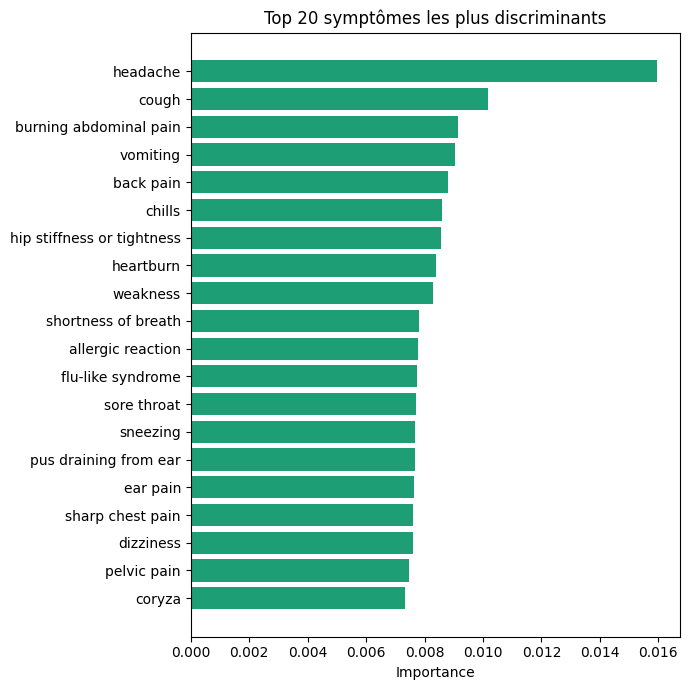

In [13]:
importances = pd.Series(model.feature_importances_, index=symptom_columns).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color="#1D9E75")
ax.set_xlabel("Importance")
ax.set_title("Top 20 symptômes les plus discriminants")
plt.tight_layout()
plt.show()